# Titanic — Exploratory Data Analysis

Исследование `train`/`test` **без предобработки и обучения моделей**.

**Цель:** понять структуру данных, пропуски, распределения и связь признаков с `Survived`, чтобы обосновать feature engineering и выбор моделей.

**Вопросы:**
1. Насколько несбалансирован таргет?
2. Какие признаки сильнее всего связаны с выживаемостью?
3. Где пропуски и что с ними делать на этапе препроцессинга?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


def _project_root() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        if (base / "data" / "train.csv").exists():
            return base.resolve()
    raise FileNotFoundError(
        "Не найден data/train.csv. Запускайте ноутбук из корня репозитория или из notebooks/."
    )


root = _project_root()
train_path = root / "data" / "train.csv"
test_path = root / "data" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train path: {train_path.resolve()}")
print(f"Test path:  {test_path.resolve()}")
print(f"train_df.shape = {train_df.shape}")
print(f"test_df.shape  = {test_df.shape}")

Train path: C:\education\titanic\data\train.csv
Test path:  C:\education\titanic\data\test.csv
train_df.shape = (891, 12)
test_df.shape  = (418, 11)


In [2]:
# Быстрый взгляд на данные
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Базовая информация по столбцам
train_df.info()

print("\nЧисловые признаки (describe):")
display(train_df.describe().T)

print("\nКатегориальные признаки (describe):")
cat_desc = train_df.describe(include=["object", "str"]).T
if not cat_desc.empty:
    display(cat_desc)
else:
    print("Категориальных признаков нет")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Числовые признаки (describe):


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



Категориальные признаки (describe):


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


### Вывод: обзор таблицы

- В train **891** строка и **12** столбцов, в test **418** строк без таргета.
- Признаки смешанные: числовые (`Age`, `Fare`, `SibSp`, `Parch`), категориальные (`Pclass`, `Sex`, `Embarked`) и текстовые (`Name`, `Ticket`, `Cabin`).
- Доля выживших в train ≈ **38%** — классы заметно несбалансированы, это важно для метрики (accuracy) и для интерпретации модели.
- `Name` и `Ticket` на первый взгляд выглядят как шум, но из `Name` можно извлечь титул и фамилию — это один из самых сильных источников новых признаков в Titanic.

Топ-15 признаков по числу пропусков:


,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


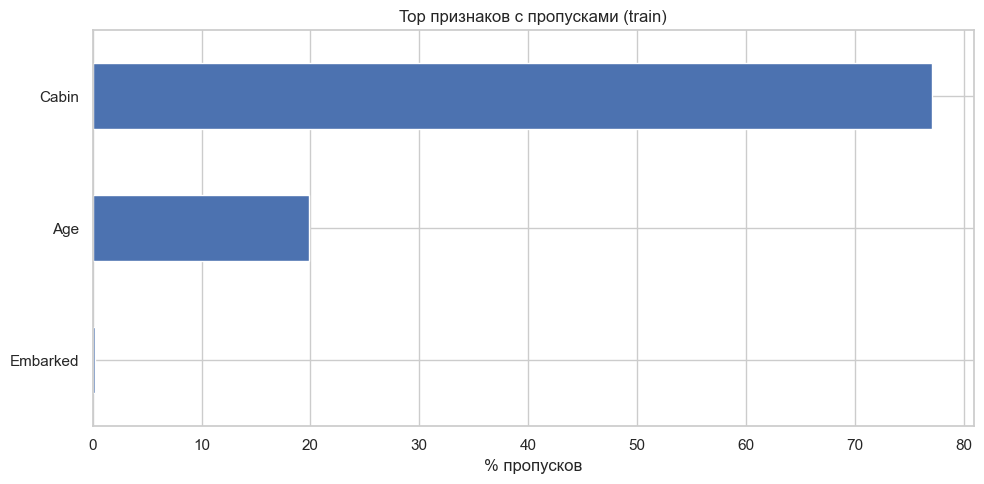

In [4]:
# Пропуски
missing_cnt = train_df.isna().sum(axis=0).sort_values(ascending=False)
missing_pct = (train_df.isna().mean(axis=0) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_cnt,
    "missing_percent": missing_pct.round(2),
})

print("Топ-15 признаков по числу пропусков:")
display(missing_table.head(15))

plot_table = (
    missing_table.query("missing_count > 0")
    .head(15)
    .sort_values(by="missing_percent", ascending=True)
)

plt.figure(figsize=(10, 5))
plot_table["missing_percent"].plot(kind="barh")
plt.title("Top признаков с пропусками (train)")
plt.xlabel("% пропусков")
plt.tight_layout()
plt.show()

### Вывод: пропуски

| Признак | ~% пропусков | Интерпретация |
|---------|-------------|---------------|
| `Cabin` | 77% | признак почти пустой → лучше `HasCabin` / буква палубы |
| `Age` | 20% | доменная imputation (пол, класс, титул), не глобальная медиана |
| `Embarked` | <1% | заполнение модой (`S`) |

Пропуски не случайны: у пассажиров 3-го класса реже указана каюта. Стратегию imputation нужно fit только на train внутри CV-фолда.

Доля выживших: 0.384


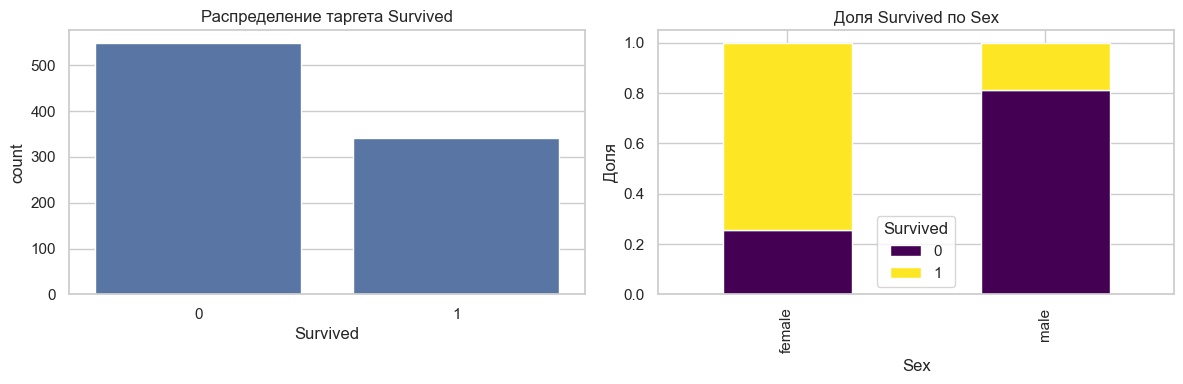

In [5]:
# Анализ таргета
if "Survived" in train_df.columns:
    survival_rate = train_df["Survived"].mean()
    print(f"Доля выживших: {survival_rate:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(data=train_df, x="Survived", ax=axes[0])
    axes[0].set_title("Распределение таргета Survived")

    by_sex = pd.crosstab(train_df["Sex"], train_df["Survived"], normalize="index")
    by_sex.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
    axes[1].set_title("Доля Survived по Sex")
    axes[1].set_ylabel("Доля")
    axes[1].legend(title="Survived")

    plt.tight_layout()
    plt.show()
else:
    print("Колонка Survived не найдена")

### Вывод: таргет и пол

- Таргет несбалансирован: выжили **~38%** пассажиров.
- **Пол — сильнейший сигнал:**
  - female: **~74%** survival rate
  - male: **~19%** survival rate
- Картина соответствует правилу «women and children first»; простое правило «женщина → Survived=1» — сильный baseline.

Для моделей: признак `IsWoman`, stratified CV, при необходимости class weights.

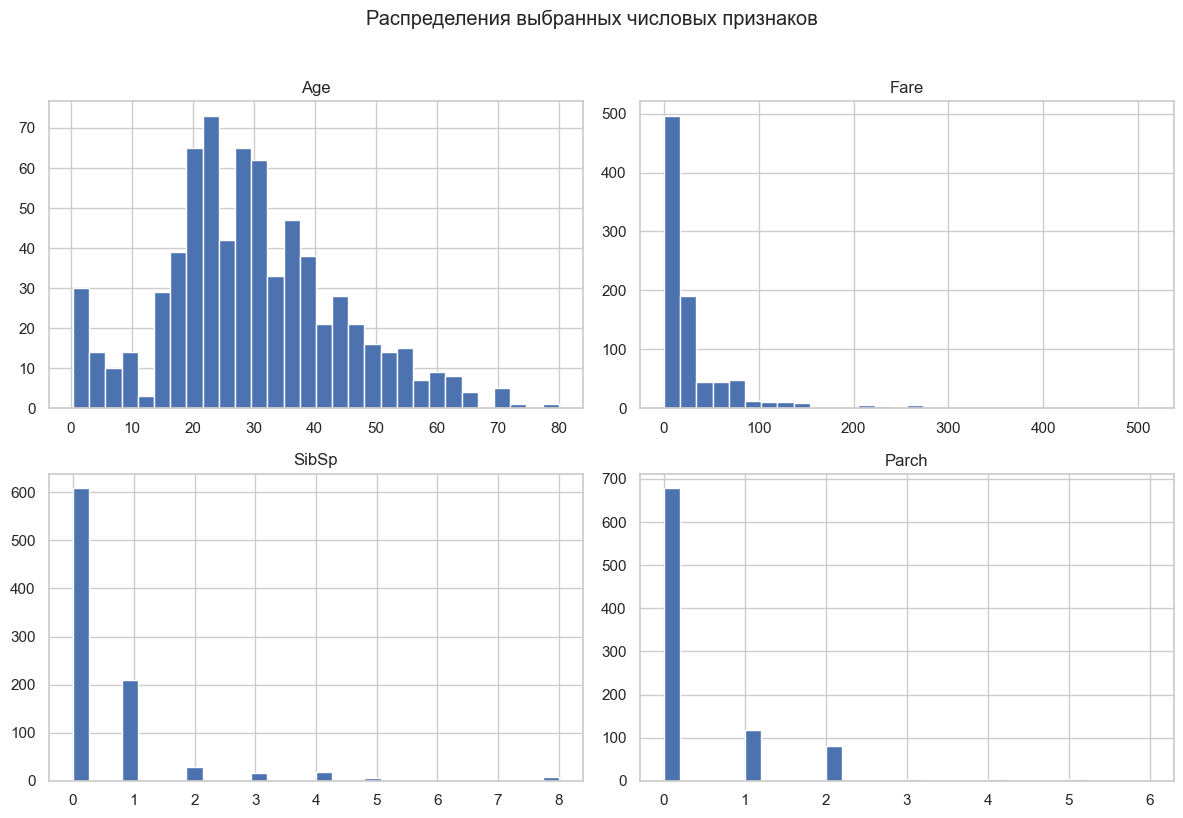

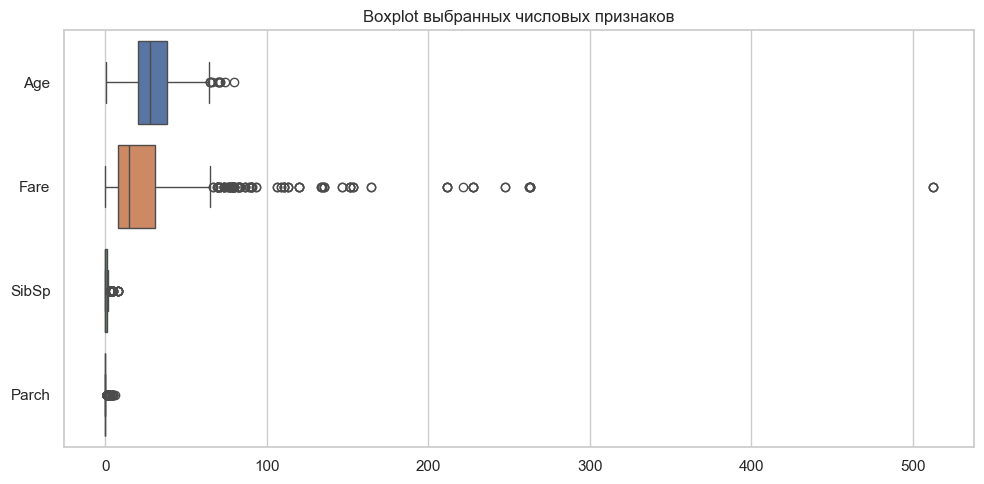

In [6]:
# Базовые распределения числовых признаков
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_wo_target = [c for c in num_cols if c != "Survived"]

selected_num = [c for c in ["Age", "Fare", "SibSp", "Parch"] if c in num_cols_wo_target]
if not selected_num:
    selected_num = num_cols_wo_target[:4]

if selected_num:
    num_plot_df = train_df.loc[:, selected_num].copy()

    num_plot_df.hist(figsize=(12, 8), bins=30)
    plt.suptitle("Распределения выбранных числовых признаков", y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=num_plot_df, orient="h")
    plt.title("Boxplot выбранных числовых признаков")
    plt.tight_layout()
    plt.show()
else:
    print("Числовые признаки не найдены")

### Вывод: числовые признаки

- **`Fare`** сильно скошен вправо → полезны `log1p(Fare)` и биннинг.
- **`Age`** — широкий диапазон, без imputation распределение «рваное».
- **`SibSp` / `Parch`** по отдельности слабые, но вместе задают размер семьи.
- Выбросы по `Fare` (1-й класс) — для линейных моделей clipping или робастная шкала.

Корреляция `Fare` с `Survived` положительная (~0.26): более дорогой билет связан с более высоким шансом выжить.

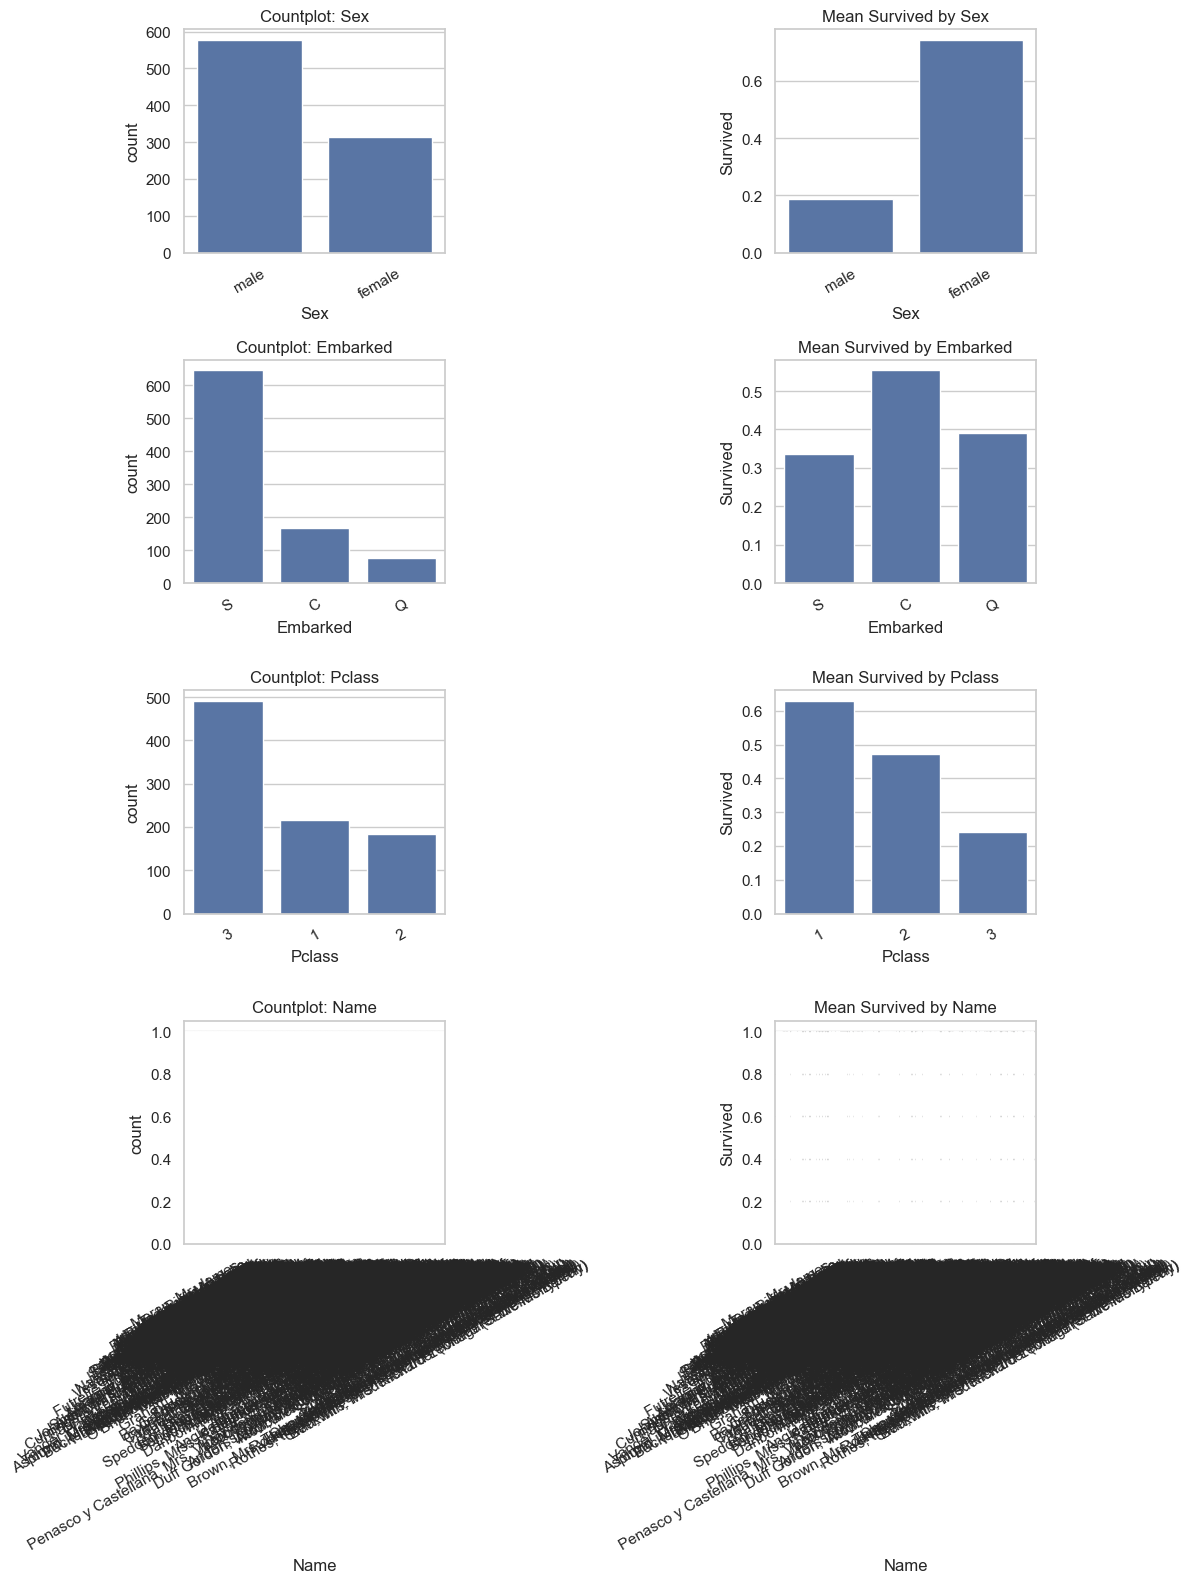

In [7]:
# Категориальные признаки: частоты и связь с таргетом
cat_cols = train_df.select_dtypes(include=["object", "str"]).columns.tolist()
selected_cat = [c for c in ["Sex", "Embarked", "Pclass"] if c in train_df.columns]
for c in cat_cols:
    if c not in selected_cat:
        selected_cat.append(c)
selected_cat = selected_cat[:4]

if selected_cat:
    n_rows = len(selected_cat)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for i, col in enumerate(selected_cat):
        count_df = train_df.loc[:, [col]].dropna().copy()
        order = count_df[col].value_counts().index
        sns.countplot(data=count_df, x=col, order=order, ax=axes[i, 0])
        axes[i, 0].set_title(f"Countplot: {col}")
        axes[i, 0].tick_params(axis="x", rotation=30)

        if "Survived" in train_df.columns:
            surv_plot_df = pd.DataFrame(
                train_df.loc[:, [col, "Survived"]].dropna()
            )
            sns.barplot(
                data=surv_plot_df,
                x=col,
                y="Survived",
                estimator=np.mean,
                errorbar=None,
                ax=axes[i, 1],
            )
            axes[i, 1].set_title(f"Mean Survived by {col}")
            axes[i, 1].tick_params(axis="x", rotation=30)
        else:
            axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Категориальные признаки не найдены")

### Вывод: категориальные признаки

- **`Pclass`** — один из сильнейших предикторов:
  - 1-й класс: **~63%** выжили
  - 2-й класс: **~47%**
  - 3-й класс: **~24%**
- **`Embarked`**: Cherbourg (C) — выше survival rate (~55%), Southampton (S) — ниже (~34%); вероятно, прокси для класса и пола.
- **`Sex`** подтверждает огромный разрыв male/female.


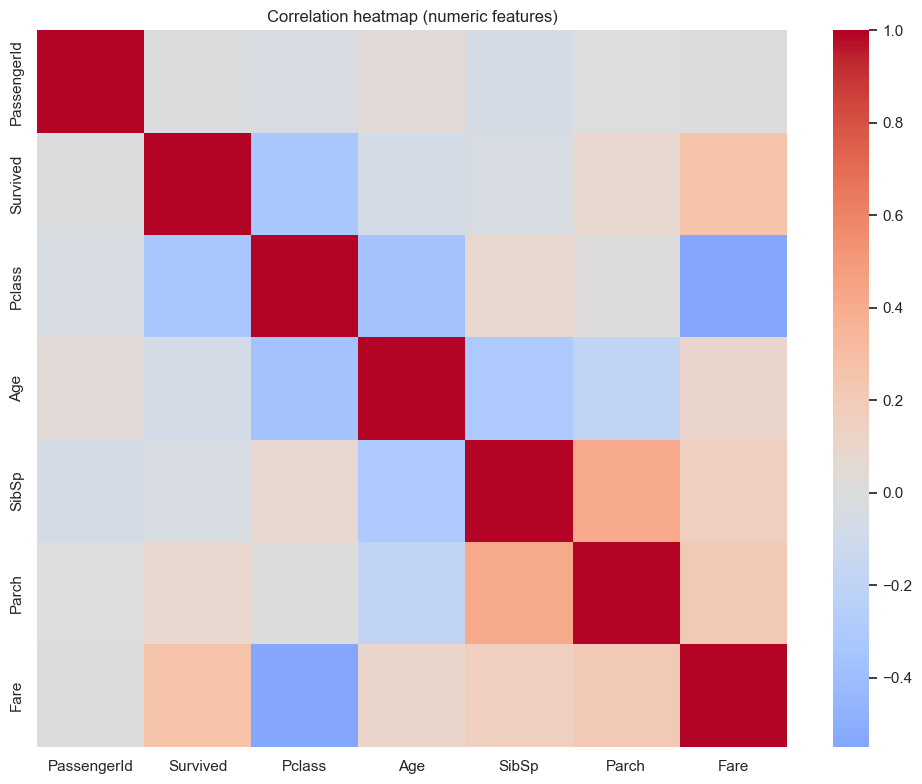

Топ корреляций с Survived (по модулю):


,abs_corr_with_survived
Pclass,0.338481
Fare,0.257307
Parch,0.081629
Age,0.077221
SibSp,0.035322
PassengerId,0.005007


In [8]:
# Корреляции числовых признаков
corr_df = train_df.select_dtypes(include=[np.number]).copy()
if corr_df.shape[1] >= 2:
    corr_matrix = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()

    if "Survived" in corr_matrix.columns:
        survived_corr = corr_matrix["Survived"]
        survived_corr = survived_corr.loc[survived_corr.index != "Survived"].abs()
        corr_target = survived_corr.sort_values(ascending=False)
        print("Топ корреляций с Survived (по модулю):")
        display(corr_target.head(10).to_frame("abs_corr_with_survived"))
else:
    print("Недостаточно числовых признаков для корреляционной матрицы")

### Вывод: корреляции

По модулю корреляции с `Survived` (числовые признаки):

1. **`Pclass`** ≈ −0.34 — чем хуже класс, тем ниже шанс выжить
2. **`Fare`** ≈ +0.26 — более высокий билет связан с выживанием
3. **`Parch`, `Age`, `SibSp`** — слабее по отдельности

`Pclass` и `Fare` связаны между собой. Для линейных моделей — регуляризация или удаление одного из признаков.

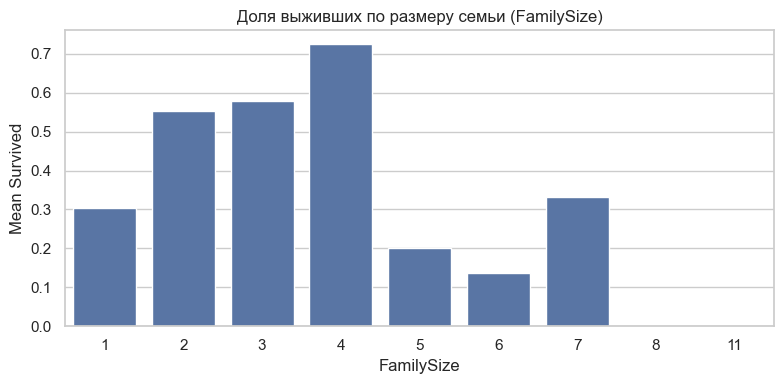

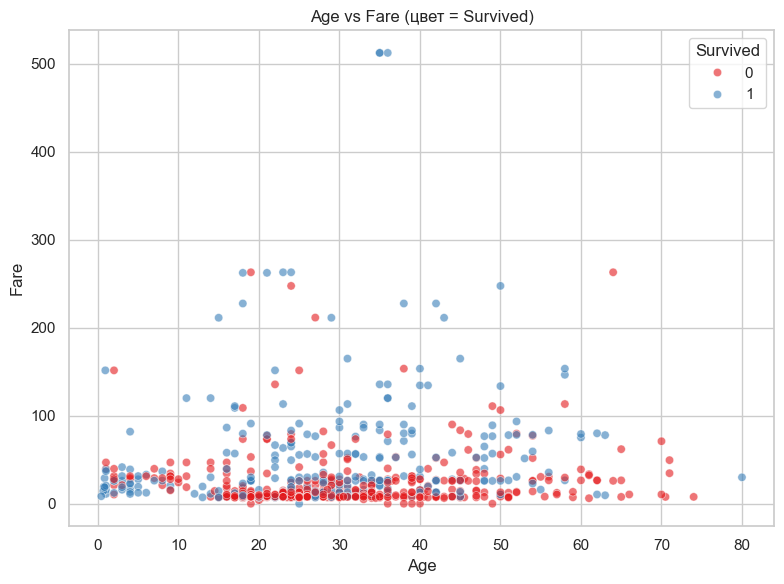

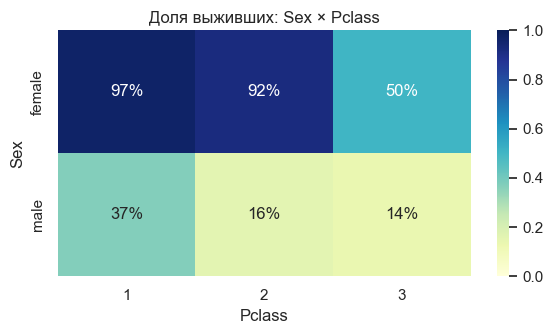

In [9]:
# Небольшой дополнительный базовый EDA от себя
# 1) Семейный размер и доля выживших
if {"SibSp", "Parch", "Survived"}.issubset(train_df.columns):
    tmp = train_df.copy()
    tmp["FamilySize"] = tmp["SibSp"] + tmp["Parch"] + 1
    fs_df = pd.DataFrame(
        tmp.groupby("FamilySize", as_index=False).agg(Survived=("Survived", "mean"))
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=fs_df, x="FamilySize", y="Survived", errorbar=None)
    plt.title("Доля выживших по размеру семьи (FamilySize)")
    plt.ylabel("Mean Survived")
    plt.tight_layout()
    plt.show()

# 2) Age vs Fare
if {"Age", "Fare", "Survived"}.issubset(train_df.columns):
    scatter_df = pd.DataFrame(train_df.loc[:, ["Age", "Fare", "Survived"]].dropna())

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=scatter_df,
        x="Age",
        y="Fare",
        hue="Survived",
        alpha=0.6,
        palette="Set1",
    )
    plt.title("Age vs Fare (цвет = Survived)")
    plt.tight_layout()
    plt.show()

# 3) Heatmap: Sex × Pclass — доля выживших
if {"Sex", "Pclass", "Survived"}.issubset(train_df.columns):
    pivot = train_df.pivot_table(
        index="Sex", columns="Pclass", values="Survived", aggfunc="mean"
    )

    plt.figure(figsize=(6, 3.5))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Доля выживших: Sex × Pclass")
    plt.tight_layout()
    plt.show()

### Вывод: семья и взаимодействия

- **Размер семьи (`FamilySize = SibSp + Parch + 1`):**
  - одиночки (1): **~30%** выжили — ниже среднего
  - семьи 2–4 человека: **~55–72%** — выше среднего
  - большие семьи (5+): снова падение survival rate
- **Sex × Pclass** (heatmap): эффект пола усиливается классом — женщины 1-го класса выживали **~97%**, мужчины 3-го класса — **~14%**. Одного пола или класса недостаточно, важна комбинация.
- На scatter **Age vs Fare** выжившие чаще в зоне высокого `Fare` (1-й класс).

Имеет смысл признаки `FamilySize`, `IsAlone`, `FamilySizeBin`, а также взаимодействия `Sex × Pclass`, `Age × Pclass`.

## Итоговые выводы и гипотезы для моделирования

### Главные закономерности

1. **Пол** — доминирующий фактор (~74% vs ~19% survival).
2. **Класс каюты (`Pclass`)** — чем ниже класс, тем ниже шанс выжить (63% → 24%).
3. **Стоимость билета (`Fare`)** — прокси богатства и доступа к шлюпкам.
4. **Размер семьи** — нелинейный эффект: оптимум у семей 2–4 человека.
5. **Пропуски** — структурные (`Cabin`, `Age`), требуют осмысленной imputation.

### Что стоит сделать в feature engineering (не в этом ноутбуке)

| Признак | Идея |
|---------|------|
| `Name` | извлечь `Title`, `Surname` (группировка семей) |
| `Cabin` | `HasCabin`, буква палубы (`Deck`) |
| `Age` | imputation по полу/классу/титулу, биннинг, `IsChild` |
| `Fare` | `log1p`, биннинг, `FarePerPerson` |
| Семья | `FamilySize`, `IsAlone`, `FamilySizeBin` |
| Взаимодействия | `Sex × Pclass`, `Age × Pclass` |

### Baseline и модели

- **Rule baseline:** женщина → Survived=1 — уже конкурентный ориентир.
- **Линейные модели** выиграют от encoding категорий и масштабирования `Fare`.
- **Деревья / бустинги** хорошо подхватят нелинейности (`FamilySize`, `Title`) без ручных взаимодействий.
- **Метрика:** accuracy на Kaggle, но из-за дисбаланса полезно смотреть и precision/recall по классам.

Предобработка и обучение моделей намеренно вынесены в `ml/` и `dl/`.